# Informe de Análisis Descriptivo — Matrículas de Educación Superior 2021
## Región de Arica y Parinacota

**Asignatura**: MAT4141 — Estadística Descriptiva
**Fuente de datos**: Registro de Matrícula de Educación Superior año 2021 (SIES), archivo
`01_MATRICULAS_ED_SUPERIOR_ARICA_Y_PARINACOTA_2021.xlsx`.

Las 28 variables del archivo están descritas en el *diccionario de variables* (`docs/diccionario_variables.pdf`).
El análisis se desarrolla con las funciones del **Formulario Python MAT4141** (tablas de frecuencia con
`groupby` y `pd.cut`, gráficos con `matplotlib`, medidas de tendencia central y percentiles),
complementado con `pd.crosstab` para las tablas de dos variables.

## 1. Introducción

El presente informe describe la **matrícula de educación superior de la Región de Arica y Parinacota
durante el año 2021**. El objetivo es caracterizar quién se matricula (edad), dónde lo hace (tipo y
nombre de institución, jornada) y cuánto paga (valor de matrícula y arancel), aplicando herramientas
de estadística descriptiva: tablas de frecuencia, gráficos, medidas de tendencia central y percentiles.

El informe se organiza en las siguientes secciones:

1. **Introducción** (esta sección).
2. **Caracterización de la población y muestra**.
3. **Descripción de las variables seleccionadas**.
4. **Análisis univariado**: tablas de frecuencia, gráficos, medidas de tendencia central y percentiles por variable.
5. **Tablas bivariadas**: cruces entre pares de variables.
6. **Pregunta del Ítem 2 desarrollada**: ¿qué influencia tiene la edad en el tipo de institución a la que ingresan los estudiantes?
7. **Conclusiones**.

## 2. Caracterización de la población y muestra

- **Población**: el total de matrículas de educación superior registradas en la Región de Arica y
  Parinacota durante el año 2021.
- **Muestra trabajada**: el archivo entrega el **censo completo de esa matrícula**: 14.116 registros
  y 28 variables.
- **Unidad de análisis**: cada fila es una **matrícula**, no un estudiante. Un estudiante matriculado
  en dos carreras aparece dos veces; por eso se habla de matrículas y no de personas.
- **Contexto regional**: la oferta regional la concentra la **Universidad de Tarapacá** (estatal,
  perteneciente al CRUCH); el resto se reparte entre Centros de Formación Técnica (CFT), Institutos
  Profesionales (IP) y Universidades Privadas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../raw/01_MATRICULAS_ED_SUPERIOR_ARICA_Y_PARINACOTA_2021.xlsx")

In [2]:
#Dimensiones del conjunto y primeras filas
print(f"El conjunto tiene {df.shape[0]} matrículas y {df.shape[1]} variables.")
df.head(5)

El conjunto tiene 14116 matrículas y 28 variables.


,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,1,Femenino,22,20 a 24,2019,Primer semestre,Centros de Formacion Tecnica,CFT DE TARAPACA,NO ACREDITADA,NaN,...,Carreras Tecnicas,Salud,5,1,5,120000,1823000,Arica y Parinacota,Arica,Arica
1,27,Femenino,26,25 a 29,2020,Primer semestre,Institutos Profesionales,IP SANTO TOMAS,ACREDITADA,20/01/2021 AL 20/01/2026,...,Carreras Profesionales,Administracion y Comercio,4,0,4,89000,1855000,Arica y Parinacota,Arica,Arica
2,38,Masculino,24,20 a 24,2015,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE TARAPACA,ACREDITADA,22/11/2017 AL 22/11/2022,...,Carreras Profesionales,Salud,10,1,10,155000,3533000,Arica y Parinacota,Arica,Arica
3,193,Femenino,23,20 a 24,2016,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE TARAPACA,ACREDITADA,22/11/2017 AL 22/11/2022,...,Carreras Profesionales,Salud,10,1,10,155000,3533000,Arica y Parinacota,Arica,Arica
4,472,Femenino,20,20 a 24,2019,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE TARAPACA,ACREDITADA,22/11/2017 AL 22/11/2022,...,Carreras Profesionales,Educacion,10,1,10,155000,2857000,Arica y Parinacota,Arica,Arica


## 3. Variables seleccionadas

De las 28 variables del archivo se seleccionaron las más relevantes para describir la matrícula:

| Variable | Tipo | Escala | Descripción |
|---|---|---|---|
| `EDAD` | Cuantitativa continua | Razón | Edad del matriculado en años |
| `RANGO EDAD` | Cualitativa ordinal | Intervalos | Tramo etario oficial (15 a 19, 20 a 24, …, 40 y más) |
| `VALOR ARANCEL (PESOS)` | Cuantitativa continua | Razón | Arancel anual del programa en pesos |
| `VALOR MATRICULA (PESOS)` | Cuantitativa continua | Razón | Valor de la matrícula anual en pesos |
| `TIPO DE INSTITUCION` | Cualitativa nominal | Nominal | CFT, IP, Universidades CRUCH o Privadas |
| `NOMBRE DE INSTITUCION` | Cualitativa nominal | Nominal | Institución específica |
| `JORNADA` | Cualitativa nominal | Nominal | Diurno, Vespertino, Otro o Semipresencial |

En la Sección 4 se analiza cada variable por separado (tablas de frecuencia, gráficos y medidas de
posición). En la Sección 5 se analizan de a pares.

## 4. Análisis univariado

Para las variables **cuantitativas** el número de intervalos se determina con la **regla de Sturges**:
$k = 1 + \log_2 n$. Con $n = 14.116$, $k \approx 15$; los bordes se ajustan a valores redondos de
ancho fijo para evitar intervalos vacíos.

### 4.1 Variable cuantitativa: `EDAD`

**Criterio de intervalos**: Sturges da $k \approx 15$; se usan 15 intervalos de ancho fijo 4 años
entre 16 y 76 años.

In [3]:
#Sturges e intervalos de ancho fijo 4 años
k = int(round(1 + np.log2(df.shape[0])))   # k = 15
intervalos_edad = np.arange(16, 77, 4)     # [16,20), [20,24), ..., [72,76)

df['Intervalos EDAD'] = pd.cut(df['EDAD'], bins=intervalos_edad, include_lowest=True, precision=0)
frecuencia = df.groupby('Intervalos EDAD', observed=True).size()

n = df.shape[0]
tabla_edad = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round(((frecuencia/n)*100).cumsum(), 1)
})
print(f"k de Sturges = {k}")
tabla_edad

k de Sturges = 15


,fi,hi,Fi,Hi
Intervalos EDAD,,,,
"(15, 20]",3209,22.7,3209,22.7
"(20, 24]",5778,40.9,8987,63.7
"(24, 28]",1857,13.2,10844,76.8
"(28, 32]",1152,8.2,11996,85.0
"(32, 36]",756,5.4,12752,90.3
"(36, 40]",510,3.6,13262,94.0
"(40, 44]",342,2.4,13604,96.4
"(44, 48]",243,1.7,13847,98.1
"(48, 52]",155,1.1,14002,99.2


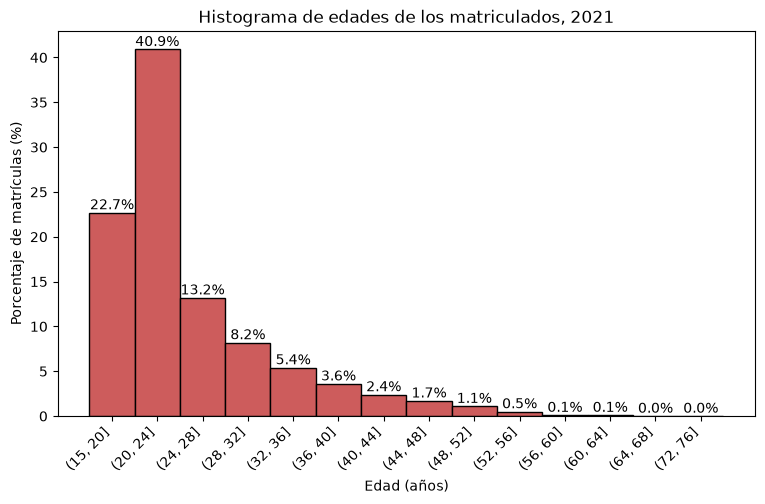

In [4]:
#Histograma: EDAD
fig, ax = plt.subplots(figsize=(9,5))
histograma = ax.bar(tabla_edad.index.astype(str), tabla_edad['hi'], color='indianred', edgecolor='black', width=1)
ax.set_title('Histograma de edades de los matriculados, 2021')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.bar_label(histograma, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')
plt.show()

In [5]:
#Medidas de tendencia central y percentiles: EDAD
media_edad = df['EDAD'].mean()
mediana_edad = df['EDAD'].median()
moda_edad = df['EDAD'].mode()[0]
p25_edad = df['EDAD'].quantile(0.25)
p50_edad = df['EDAD'].quantile(0.50)
p75_edad = df['EDAD'].quantile(0.75)
p90_edad = df['EDAD'].quantile(0.90)

resumen_edad = pd.DataFrame({
    'Medida': ['Media', 'Mediana', 'Moda', 'P25', 'P50', 'P75', 'P90', 'Mínimo', 'Máximo'],
    'Valor': [round(media_edad,1), mediana_edad, moda_edad, p25_edad, p50_edad, p75_edad, p90_edad,
              df['EDAD'].min(), df['EDAD'].max()]
})
resumen_edad

,Medida,Valor
0,Media,25.5
1,Mediana,23.0
2,Moda,19.0
3,P25,21.0
4,P50,23.0
5,P75,28.0
6,P90,36.0
7,Mínimo,18.0
8,Máximo,75.0


**Interpretación — `EDAD`**: la distribución es **asimétrica a la derecha**: la media (25,5 años)
supera a la mediana (23 años) y la moda es 19 años. El 50 % central de las matrículas tiene entre
21 y 28 años (P25 y P75) y el percentil 90 es 36 años: solo el 10 % de las matrículas tiene 36 años
o más, con casos extremos hasta los 75 años. En síntesis, la matrícula regional es mayoritariamente
joven, pero con una cola de adultos que se (re)incorporan a la educación superior.

### 4.2 Variable cuantitativa: `VALOR ARANCEL (PESOS)`

**Criterio de intervalos**: Sturges da $k \approx 15$; se usan intervalos de ancho fijo
\$400.000 entre \$0 y \$6.000.000.

In [6]:
#Intervalos de ancho fijo $400.000 (k = 15 según Sturges)
intervalos_arancel = np.arange(0, 6000001, 400000)

df['Intervalos ARANCEL'] = pd.cut(df['VALOR ARANCEL (PESOS)'], bins=intervalos_arancel,
                                  include_lowest=True, precision=0)
frecuencia = df.groupby('Intervalos ARANCEL', observed=True).size()

tabla_arancel = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round(((frecuencia/n)*100).cumsum(), 1)
})
tabla_arancel

,fi,hi,Fi,Hi
Intervalos ARANCEL,,,,
"(-1, 400000]",6,0.0,6,0.0
"(400000, 800000]",44,0.3,50,0.4
"(800000, 1200000]",4,0.0,54,0.4
"(1200000, 1600000]",2507,17.8,2561,18.1
"(1600000, 2000000]",1708,12.1,4269,30.2
"(2000000, 2400000]",1604,11.4,5873,41.6
"(2400000, 2800000]",488,3.5,6361,45.1
"(2800000, 3200000]",1857,13.2,8218,58.2
"(3200000, 3600000]",3667,26.0,11885,84.2


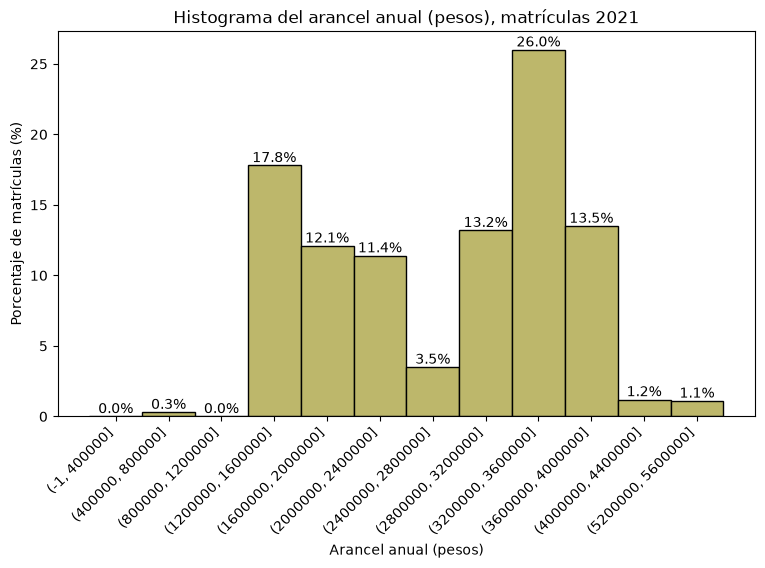

In [7]:
#Histograma: VALOR ARANCEL (PESOS)
fig, ax = plt.subplots(figsize=(9,5))
histograma = ax.bar(tabla_arancel.index.astype(str), tabla_arancel['hi'], color='darkkhaki', edgecolor='black', width=1)
ax.set_title('Histograma del arancel anual (pesos), matrículas 2021')
ax.set_xlabel('Arancel anual (pesos)')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.bar_label(histograma, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')
plt.show()

In [8]:
#Medidas de tendencia central y percentiles: VALOR ARANCEL
arancel = df['VALOR ARANCEL (PESOS)']

media_arancel = arancel.mean()
mediana_arancel = arancel.median()
moda_arancel = arancel.mode()[0]
p25_arancel = arancel.quantile(0.25)
p75_arancel = arancel.quantile(0.75)
p90_arancel = arancel.quantile(0.90)
p95_arancel = arancel.quantile(0.95)

resumen_arancel = pd.DataFrame({
    'Medida': ['Media', 'Mediana', 'Moda', 'P25', 'P75', 'P90', 'P95', 'Mínimo', 'Máximo'],
    'Valor': [round(media_arancel), mediana_arancel, moda_arancel, p25_arancel, p75_arancel,
              p90_arancel, p95_arancel, arancel.min(), arancel.max()]
})
resumen_arancel

,Medida,Valor
0,Media,2714574.0
1,Mediana,2857000.0
2,Moda,3533000.0
3,P25,1850000.0
4,P75,3533000.0
5,P90,3775000.0
6,P95,3995000.0
7,Mínimo,0.0
8,Máximo,5595000.0


**Interpretación — `VALOR ARANCEL`**: el arancel anual medio es **\$2.714.574** y el mediano
**\$2.857.000**; como la media es menor que la mediana, la distribución es **asimétrica a la
izquierda**: abundan los aranceles altos (modales en \$3.533.000, el arancel de las carreras
profesionales de la U. de Tarapacá) y hay pocos aranceles bajos. El 50 % central va de \$1.850.000
a \$3.533.000 (P25 y P75) y el 5 % más caro supera el percentil 95 (\$3.995.000).

**Dato llamativo**: existen 5 matrículas con arancel \$0, todas del Magíster en Acuicultura de la
Universidad de Tarapacá (programa de postgrado, posiblemente becado o sin arancel informado).

### 4.3 Variable cuantitativa: `VALOR MATRICULA (PESOS)`

**Criterio de intervalos**: Sturges da $k \approx 15$; se usan intervalos de ancho fijo
\$20.000 entre \$0 y \$300.000.

In [9]:
#Intervalos de ancho fijo $20.000 (k = 15 según Sturges)
intervalos_matricula = np.arange(0, 300001, 20000)

df['Intervalos MATRICULA'] = pd.cut(df['VALOR MATRICULA (PESOS)'], bins=intervalos_matricula,
                                    include_lowest=True, precision=0)
frecuencia = df.groupby('Intervalos MATRICULA', observed=True).size()

tabla_matricula = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round(((frecuencia/n)*100).cumsum(), 1)
})
tabla_matricula

,fi,hi,Fi,Hi
Intervalos MATRICULA,,,,
"(-1, 20000]",1902,13.5,1902,13.5
"(40000, 60000]",62,0.4,1964,13.9
"(60000, 80000]",717,5.1,2681,19.0
"(80000, 100000]",548,3.9,3229,22.9
"(100000, 120000]",858,6.1,4087,29.0
"(120000, 140000]",787,5.6,4874,34.5
"(140000, 160000]",6998,49.6,11872,84.1
"(160000, 180000]",228,1.6,12100,85.7
"(180000, 200000]",198,1.4,12298,87.1


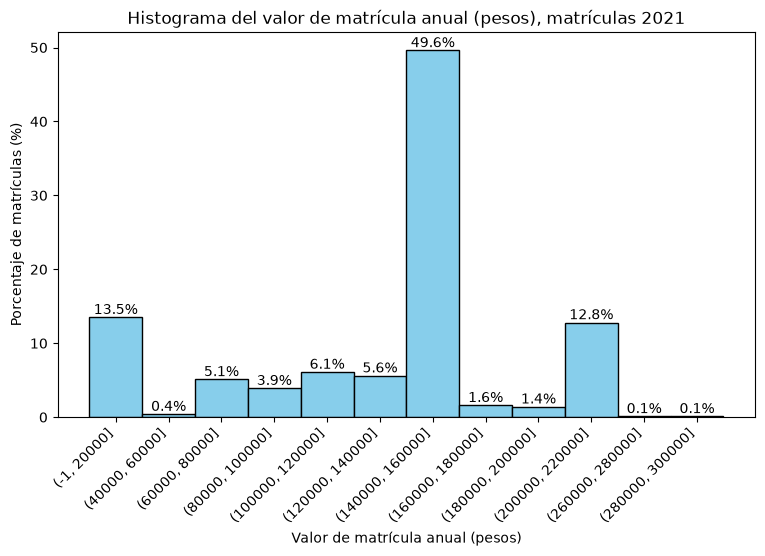

In [10]:
#Histograma: VALOR MATRICULA (PESOS)
fig, ax = plt.subplots(figsize=(9,5))
histograma = ax.bar(tabla_matricula.index.astype(str), tabla_matricula['hi'], color='skyblue', edgecolor='black', width=1)
ax.set_title('Histograma del valor de matrícula anual (pesos), matrículas 2021')
ax.set_xlabel('Valor de matrícula anual (pesos)')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.bar_label(histograma, fmt='%.1f%%')
plt.xticks(rotation=45, ha='right')
plt.show()

In [11]:
#Medidas de tendencia central y percentiles: VALOR MATRICULA
matricula = df['VALOR MATRICULA (PESOS)']

media_mat = matricula.mean()
mediana_mat = matricula.median()
moda_mat = matricula.mode()[0]
p25_mat = matricula.quantile(0.25)
p75_mat = matricula.quantile(0.75)
p90_mat = matricula.quantile(0.90)

resumen_matricula = pd.DataFrame({
    'Medida': ['Media', 'Mediana', 'Moda', 'P25', 'P75', 'P90', 'Mínimo', 'Máximo'],
    'Valor': [round(media_mat), mediana_mat, moda_mat, p25_mat, p75_mat, p90_mat,
              matricula.min(), matricula.max()]
})
resumen_matricula

,Medida,Valor
0,Media,131952.0
1,Mediana,155000.0
2,Moda,155000.0
3,P25,116000.0
4,P75,155000.0
5,P90,220000.0
6,Mínimo,0.0
7,Máximo,290504.0


**Interpretación — `VALOR MATRICULA`**: el valor medio de la matrícula es **\$131.952** y la
mediana **\$155.000** (moda y P75 también en \$155.000): a diferencia del arancel, la distribución
es **asimétrica a la izquierda y muy concentrada**, porque cada institución fija un valor único.
Destacan tres grupos: un bloque sin costo o con matrícula baja (≈ \$0–\$120.000, asociado a
beneficios/becas y a los CFT), el bloque modal en \$155.000 (49,5 % de las matrículas, valor de la
U. de Tarapacá) y un grupo en torno a \$220.000 (INACAP), lo que refleja una estructura discreta
por instituciones más que una dispersión continua.

### 4.4 Variable cualitativa: `TIPO DE INSTITUCION`

In [12]:
#Tabla de frecuencia: TIPO DE INSTITUCION (ordenada de mayor a menor fi)
frecuencia = df.groupby('TIPO DE INSTITUCION').size().sort_values(ascending=False)

tabla_tipo_inst = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round((frecuencia.cumsum()/n)*100, 1)
})

frec_institucion = df.groupby('NOMBRE DE INSTITUCION').size().sort_values(ascending=False)
tabla_instituciones = pd.DataFrame({'Matrículas': frec_institucion,
                                    'hi (%)': round((frec_institucion/n)*100, 1)})

display(tabla_tipo_inst)
display(tabla_instituciones.head(5))

,fi,hi,Fi,Hi
TIPO DE INSTITUCION,,,,
Universidades CRUCH,7849,55.6,7849,55.6
Centros de Formacion Tecnica,3594,25.5,11443,81.1
Institutos Profesionales,1430,10.1,12873,91.2
Universidades Privadas,1243,8.8,14116,100.0


,Matrículas,hi (%)
NOMBRE DE INSTITUCION,,
UNIVERSIDAD DE TARAPACA,7119,50.4
CFT DE LA REGION DE ARICA Y PARINACOTA,1896,13.4
UNIVERSIDAD SANTO TOMAS,898,6.4
CFT INACAP,807,5.7
IP INACAP,789,5.6


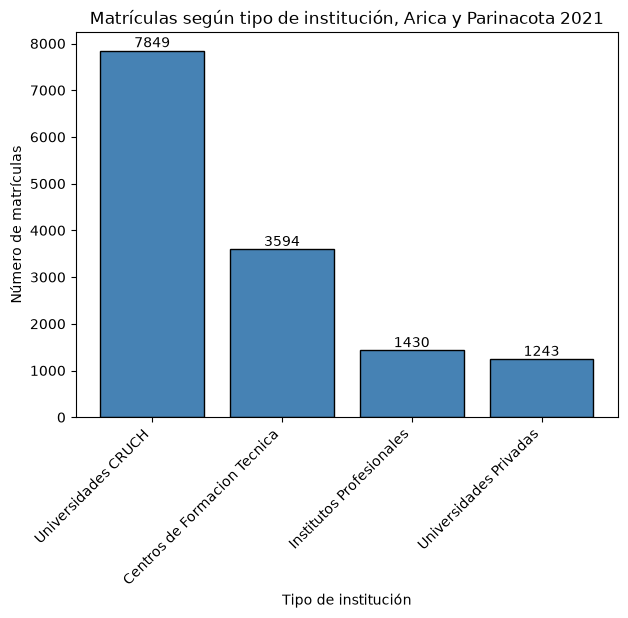

In [13]:
#Gráfico de barras: TIPO DE INSTITUCION
categorias = tabla_tipo_inst.index
f = tabla_tipo_inst['fi']

fig, ax = plt.subplots(figsize=(7,5))
barras = ax.bar(categorias, f, color='steelblue', edgecolor='black')
ax.set_title('Matrículas según tipo de institución, Arica y Parinacota 2021')
ax.set_xlabel('Tipo de institución')
ax.set_ylabel('Número de matrículas')
ax.bar_label(barras)
plt.xticks(rotation=45, ha='right')
plt.show()

**Interpretación — `TIPO DE INSTITUCION`**: las **Universidades CRUCH** concentran el 55,6 % de las
matrículas (7.849) y son la moda, seguidas por los **Centros de Formación Técnica** con 25,5 %. Los
Institutos Profesionales (10,1 %) y las Universidades Privadas (8,8 %) tienen participaciones menores.
A nivel de institución específica, la **Universidad de Tarapacá** (estatal, CRUCH) concentra por sí
sola el **50,4 %** de toda la matrícula regional (7.119 de 14.116), seguida de lejos por el CFT de la
Región de Arica y Parinacota (13,4 %) y la Universidad Santo Tomás (6,4 %). La oferta superior
regional está, por tanto, fuertemente dominada por la universidad estatal.

### 4.5 Variable cualitativa: `JORNADA`

In [14]:
#Tabla de frecuencia: JORNADA (ordenada de mayor a menor fi)
frecuencia = df.groupby('JORNADA').size().sort_values(ascending=False)

tabla_jornada = pd.DataFrame({
    'fi': frecuencia,
    'hi': round((frecuencia/n)*100, 1),
    'Fi': frecuencia.cumsum(),
    'Hi': round((frecuencia.cumsum()/n)*100, 1)
})
tabla_jornada

,fi,hi,Fi,Hi
JORNADA,,,,
Diurno,9961,70.6,9961,70.6
Vespertino,4104,29.1,14065,99.6
Otro,47,0.3,14112,100.0
Semipresencial,4,0.0,14116,100.0


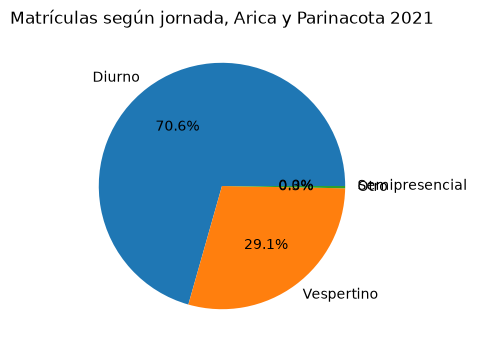

In [15]:
#Gráfico circular: JORNADA
categorias = tabla_jornada.index
h = tabla_jornada['hi']

fig, ax = plt.subplots(figsize=(6,4))
ax.pie(h, labels=categorias, autopct='%.1f%%')
ax.set_title('Matrículas según jornada, Arica y Parinacota 2021')
plt.show()

**Interpretación — `JORNADA`**: la moda es la jornada **diurna**, con 9.961 matrículas (70,6 %);
la jornada **vespertina** es la segunda opción con 29,1 %. Las categorías "Otro" (0,3 %) y
"Semipresencial" (0,0 %) son marginales. Predominan, entonces, las jornadas presenciales diurnas,
aunque casi tres de cada diez matrículas son vespertinas; esta fracción se asocia a estudiantes que
trabajan, como se analiza en la sección bivariada y en el Ítem 2.

## 5. Tablas bivariadas

Se analizan los cruces entre pares de variables con tablas de doble entrada (`pd.crosstab`) y
porcentajes por fila.

### 5.1 `RANGO EDAD` × `TIPO DE INSTITUCION`

**Criterio**: dentro de cada tramo de edad (filas), ¿cómo se distribuyen las matrículas entre tipos
de institución?

In [16]:
#Tabla de doble entrada con porcentajes por fila: RANGO EDAD x TIPO DE INSTITUCION
tabla_edad_tipo = pd.crosstab(df['RANGO EDAD'], df['TIPO DE INSTITUCION'], normalize='index').round(3)*100
tabla_edad_tipo = tabla_edad_tipo[['Universidades CRUCH', 'Centros de Formacion Tecnica',
                                   'Institutos Profesionales', 'Universidades Privadas']]
tabla_edad_tipo

TIPO DE INSTITUCION,Universidades CRUCH,Centros de Formacion Tecnica,Institutos Profesionales,Universidades Privadas
RANGO EDAD,,,,
15 a 19,68.3,19.9,7.0,4.7
20 a 24,60.6,21.7,9.2,8.4
25 a 29,50.6,27.5,12.1,9.8
30 a 34,39.3,35.3,14.8,10.6
35 a 39,37.1,37.5,12.4,13.1
40 y mas,33.3,40.2,12.2,14.2


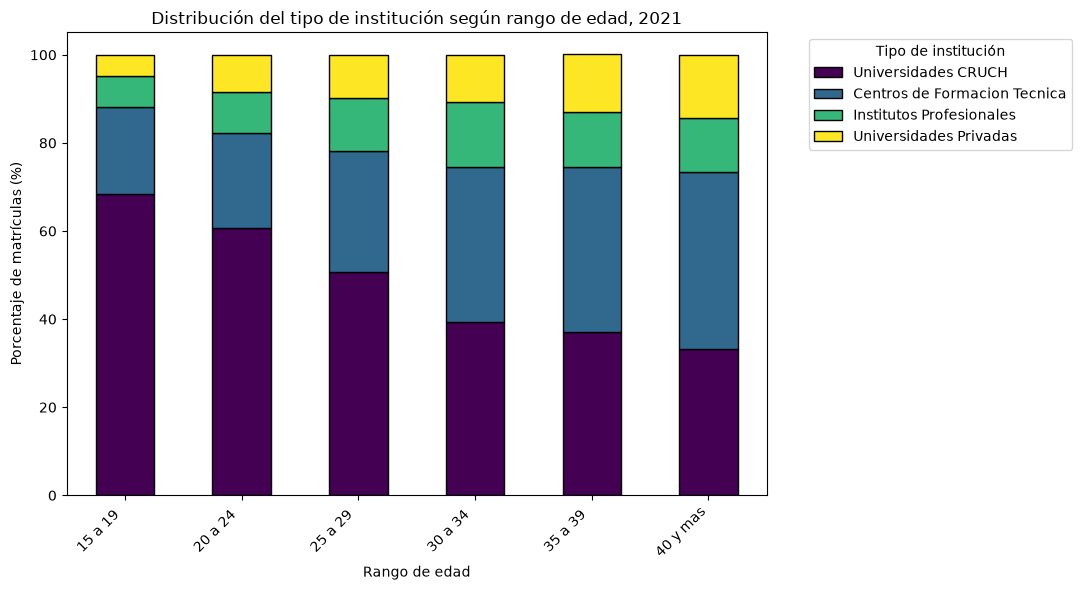

In [17]:
#Gráfico de barras apiladas: composición por tipo de institución en cada rango de edad
fig, ax = plt.subplots(figsize=(11,6))
tabla_edad_tipo.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black')
ax.set_title('Distribución del tipo de institución según rango de edad, 2021')
ax.set_xlabel('Rango de edad')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.legend(title='Tipo de institución', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretación**: existe un patrón claro y creciente. Entre los más jóvenes (15 a 19 años) el
**68,3 %** se matricula en universidades CRUCH y solo el 19,9 % en CFT; a medida que aumenta la edad,
la participación de las universidades CRUCH cae de forma sostenida hasta el **33,3 %** en el tramo
"40 y más", mientras que la de los **CFT sube hasta 40,2 %**, la de los **IP hasta 12,2 %** y la de
las **universidades privadas hasta 14,2 %**. Es decir, a mayor edad, mayor peso relativo del sector
técnico-profesional y privado; este cruce es la base empírica de la Pregunta del Ítem 2 (Sección 6).

### 5.2 `TIPO DE INSTITUCION` × `JORNADA`

**Criterio**: dentro de cada tipo de institución (filas), ¿qué proporción de su matrícula es diurna
y qué proporción vespertina?

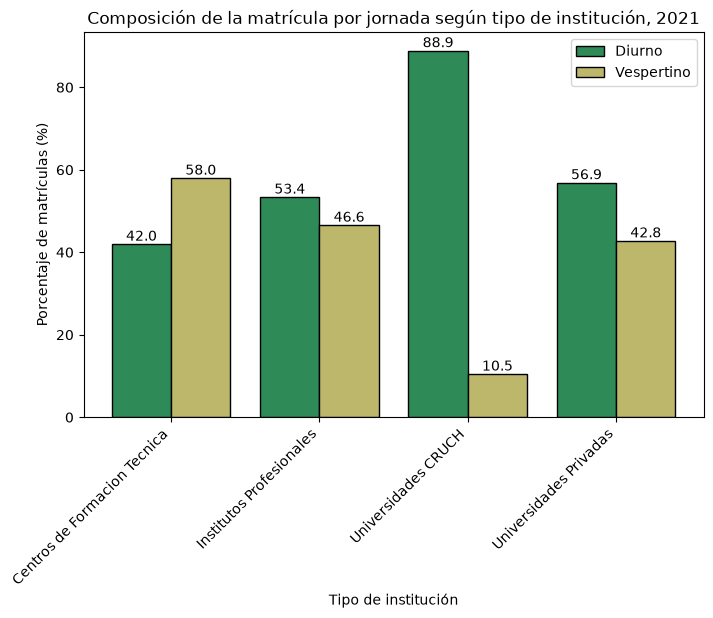

JORNADA,Diurno,Otro,Semipresencial,Vespertino
TIPO DE INSTITUCION,,,,
Centros de Formacion Tecnica,42.0,0.0,0.0,58.0
Institutos Profesionales,53.4,0.0,0.0,46.6
Universidades CRUCH,88.9,0.6,0.0,10.5
Universidades Privadas,56.9,0.0,0.3,42.8


In [18]:
#Tabla de doble entrada con porcentajes por fila: TIPO DE INSTITUCION x JORNADA
tabla_tipo_jornada = pd.crosstab(df['TIPO DE INSTITUCION'], df['JORNADA'], normalize='index').round(3)*100

x = np.arange(len(tabla_tipo_jornada))
fig, ax = plt.subplots(figsize=(8,5))
b1 = ax.bar(x - 0.2, tabla_tipo_jornada['Diurno'], width=0.4, color='seagreen', edgecolor='black', label='Diurno')
b2 = ax.bar(x + 0.2, tabla_tipo_jornada['Vespertino'], width=0.4, color='darkkhaki', edgecolor='black', label='Vespertino')
ax.set_title('Composición de la matrícula por jornada según tipo de institución, 2021')
ax.set_xlabel('Tipo de institución')
ax.set_ylabel('Porcentaje de matrículas (%)')
ax.set_xticks(x)
ax.set_xticklabels(tabla_tipo_jornada.index, rotation=45, ha='right')
ax.bar_label(b1, fmt='%.1f')
ax.bar_label(b2, fmt='%.1f')
ax.legend()
plt.show()

tabla_tipo_jornada

**Interpretación**: el cruce confirma un patrón consistente. En las **universidades CRUCH domina
la jornada diurna (88,9 %)**, coherente con estudiantes recién egresados de enseñanza media. En
cambio, en **CFT la jornada vespertina es mayoritaria (58,0 %)** y en **IP y universidades privadas
los porcentajes diurno/vespertino se acercan** (46,6 % y 42,8 % vespertino, respectivamente). Las
instituciones técnico-profesionales y privadas atienden en gran parte a estudiantes que trabajan,
lo que conecta con la mayor edad de su matrícula (Secciones 5.1 y 6).

## 6. Pregunta del Ítem 2 desarrollada

> **¿Qué influencia tiene la edad en el tipo de institución a la que ingresan los estudiantes?**

**Criterio diseñado**: se compara la **media y la mediana de la edad** en cada tipo de institución y,
adicionalmente, la tabla de doble entrada `RANGO EDAD × TIPO DE INSTITUCION` con porcentajes por fila
(Sección 5.1), que muestra cómo cambia la composición institucional de cada tramo etario. Usar la
mediana además de la media evita que los adultos extremos (hasta 75 años) distorsionen la comparación.

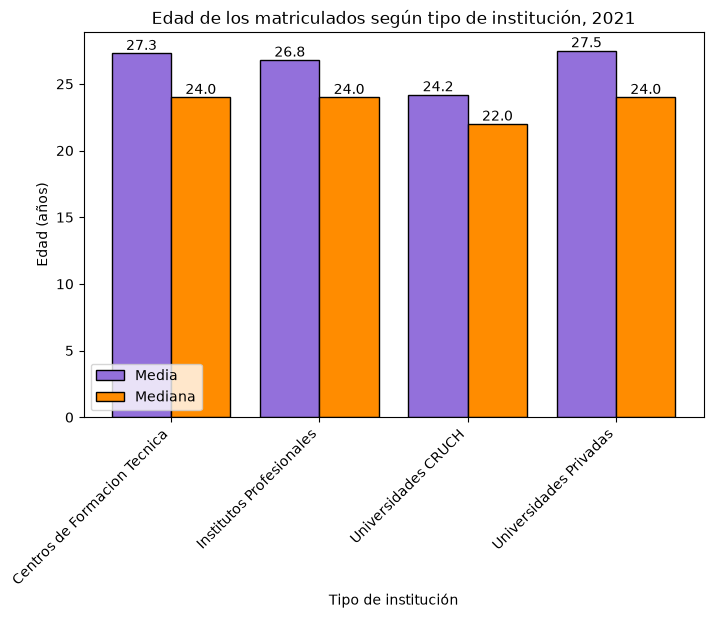

,Edad media,Edad mediana,Matrículas
TIPO DE INSTITUCION,,,
Centros de Formacion Tecnica,27.3,24.0,3594
Institutos Profesionales,26.8,24.0,1430
Universidades CRUCH,24.2,22.0,7849
Universidades Privadas,27.5,24.0,1243


In [19]:
#Media y mediana de EDAD por tipo de institución
tabla_edad_inst = df.groupby('TIPO DE INSTITUCION')['EDAD'].agg(['mean', 'median', 'size']).round(1)
tabla_edad_inst.columns = ['Edad media', 'Edad mediana', 'Matrículas']

x = np.arange(len(tabla_edad_inst))
fig, ax = plt.subplots(figsize=(8,5))
b1 = ax.bar(x - 0.2, tabla_edad_inst['Edad media'], width=0.4, color='mediumpurple',
            edgecolor='black', label='Media')
b2 = ax.bar(x + 0.2, tabla_edad_inst['Edad mediana'], width=0.4, color='darkorange',
            edgecolor='black', label='Mediana')
ax.set_title('Edad de los matriculados según tipo de institución, 2021')
ax.set_xlabel('Tipo de institución')
ax.set_ylabel('Edad (años)')
ax.set_xticks(x)
ax.set_xticklabels(tabla_edad_inst.index, rotation=45, ha='right')
ax.bar_label(b1, fmt='%.1f')
ax.bar_label(b2, fmt='%.1f')
ax.legend()
plt.show()

tabla_edad_inst

In [20]:
#P90 de edad por tipo de institución (complemento al criterio)
df.groupby('TIPO DE INSTITUCION')['EDAD'].quantile(0.90).round(1)

TIPO DE INSTITUCION
Centros de Formacion Tecnica    39.0
Institutos Profesionales        38.0
Universidades CRUCH             32.0
Universidades Privadas          40.0
Name: EDAD, dtype: float64

**Respuesta**: la edad **sí influye** de manera clara en el tipo de institución al que ingresan los
estudiantes de la región:

- **Estudiantes jóvenes → universidades CRUCH.** Las universidades CRUCH (en la práctica, la U. de
  Tarapacá) tienen la matrícula más joven: edad mediana 22 años y media 24,2. Entre los menores de
  20 años, el **68,3 %** se matricula en universidades CRUCH, frente a solo 19,9 % en CFT.
- **Estudiantes de mayor edad → sector técnico-profesional y privado.** En CFT, IP y universidades
  privadas la mediana es 24 años y la media supera los 26,8 años en los tres casos. Su percentil 90
  de edad supera los 38 años, lo que confirma que captan población adulta. La participación de las
  universidades CRUCH cae sostenidamente con la edad (68,3 % en 15-19 → **33,3 %** en 40 y más),
  mientras que la de los CFT sube de 19,9 % a **40,2 %**, la de los IP de 7,0 % a **12,2 %** y la de
  las privadas de 4,7 % a **14,2 %** (Sección 5.1).
- **Interpretación en el contexto regional**: la universidad estatal capta al egresado reciente de
  enseñanza media vía admisión tradicional, con jornada diurna (88,9 %). Los CFT, IP y universidades
  privadas —con jornada mayoritariamente o parcialmente vespertina (58 % en CFT) y carreras más
  cortas— atienden a adultos que trabajan o buscan reconversión laboral. La relación entre **edad,
  jornada y tipo de institución** es coherente entre sí: a mayor edad, mayor probabilidad de estudiar
  de tarde en una institución técnico-profesional.

## 7. Conclusiones

1. **Perfil de la matrícula**: la matrícula 2021 de Arica y Parinacota (14.116 registros) es
   mayoritariamente **joven** (mediana 23 años, moda 19; el 50 % central entre 21 y 28 años) y con
   asimetría a la derecha por la presencia de adultos de hasta 75 años.
2. **Estructura de la oferta**: la educación superior regional está **fuertemente concentrada** en la
   Universidad de Tarapacá (50,4 % de las matrículas; CRUCH 55,6 %). Las universidades privadas son
   la opción menos habitual (8,8 %).
3. **Costos**: el arancel anual mediano es **\$2.857.000** con distribución asimétrica a la izquierda
   (moda en \$3.533.000, correspondiente a las carreras profesionales de la UTA); el valor de
   matrícula es mucho más concentrado (mediana \$155.000), pues cada institución fija un valor único.
4. **Edad y elección institucional (Ítem 2)**: la edad **ordena el sistema regional**: los jóvenes
   van a las universidades CRUCH en jornada diurna; los adultos se orientan a CFT, IP y universidades
   privadas, con jornada vespertina y ofertas más cortas y flexibles.
5. **Limitaciones y proyecciones**: cada fila es una matrícula y no un estudiante único, por lo que
   los resultados describen matrículas. Como proyección, un análisis futuro puede incorporar el
   arancel por área de conocimiento y nivel de carrera, y examinar carreras con aranceles
   sustantivamente más altos que la mayoría (percentil 95).